# 서비스 문제 정의

KPI 설정, 데이터를 분석하고, 시각화하고, 보고서를 작성하고, 요약을 수행했다고 가정해보겠다. 이 과정을 통해서 도출된 보고서는 무엇이 일어났는가는 정확히 이야기할 수 있지만, 그것이 누구에게 왜 문제인가는 이야기하지 않는다.

서비스 기획을 출발점인 문제정의에 대해서 살펴보겠다.

## 문제정의에서 문제란 무엇인가

매일 20분 걸리는 출근시간이 어느날 40분이 걸렸다. 길이 막힌다 라는 문제를 느낀다. 이 길을 처음가는 사람은 40분걸리면 그냥 그런가 보다 한다. 같은 40분이라는 상황이 누구에게는 문제이고 누구에는 문제가 아닐수 있다. 기대하던 상태와 지금의 상태에서 차익아 발생하기 때문이다.

문제를 단순히 정의해보면, 기대상태와 현재상태의 차이정도로 정리해볼수 있다. 기대상태 이정도면 괜찮아의 수준이고, 현재상태는 실제로 관찰한 지금시점의 상태를 의미한다. 차이가 없으면 문제가 없거나 적은거고, 차이가 크면 문제가 크다고 볼 수 있다.

기대상태를 누가 정하는가가 중요해진다. 관제 담당자가 기대하는 한시간에 들어오는 배의 수와 선사가 기대하는 입항까지 걸리는 시간은 서로 다른 지표이지만 같은 목표를 두고 기대수준이 달라진다.

서비스를 기획할때 누구의 입장으로서 문제를 정의한것인지를 명확히 하는것이 권장된다.

- 차이 = 현재 상태 - 기대 상태
- 차이율 =  차이 / 기대상태 * 100

In [3]:
views = [
    {
        '누구': '관제 담당자',
        '지표': '시간당 최대 입항 척수',
        '기대': 11,
        '현재': 15,
        '클수록 나쁨': True
    },
    {
        '누구': '터미널 선석 담당자',
        '지표': '하루 컨테이너선 입항 척수',
        '기대': 39,
        '현재': 47,
        '클수록 나쁨': True
    },
    {
        '누구': '항만공사 운영 담당자',
        '지표': '하루 전체 입항 척수',
        '기대': 127,
        '현재': 189,
        '클수록 나쁨': False
    },
]

for v in views:
    gap = v['현재'] - v['기대']
    gap_rate = gap / v['기대'] * 100

    is_problem = (gap > 0) == v['클수록 나쁨']

    print(f"""
    {v['누구']}: {v['지표']} 차이 {gap} ({gap_rate:.1f}%) = {'문제' if is_problem else '문제아님'}
""".strip())



관제 담당자: 시간당 최대 입항 척수 차이 4 (36.4%) = 문제
터미널 선석 담당자: 하루 컨테이너선 입항 척수 차이 8 (20.5%) = 문제
항만공사 운영 담당자: 하루 전체 입항 척수 차이 62 (48.8%) = 문제아님


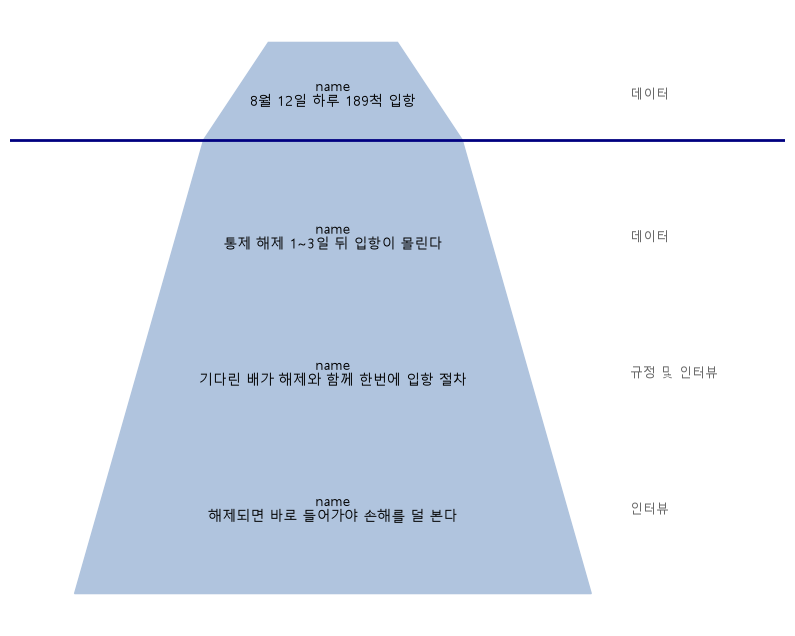

In [5]:
from matplotlib.patches import Polygon
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


layers = [
    ('사건', '8월 12일 하루 189척 입항', '데이터'),
    ('패턴', '통제 해제 1~3일 뒤 입항이 몰린다', '데이터'),
    ('구조', '기다린 배가 해제와 함께 한번에 입항 절차', '규정 및 인터뷰'),
    ('생각', '해제되면 바로 들어가야 손해를 덜 본다', '인터뷰')
]

fig, ax = plt.subplots(figsize=(10, 8))

ax.add_patch(
    Polygon(
        [ [4, 9], [3, 7.5], [1, 0.5], [9, 0.5], [7, 7.5], [6, 9] ],
        closed=True,
        color='lightsteelblue'
    )
)

ax.axhline(7.5, color='navy', linewidth=2)

label_y = [ 8.2, 6.0, 3.9, 1.8 ]

for (name, example, source), y in zip(layers, label_y):
    ax.text(5, y, f'name\n{example}', ha='center', va='center', fontsize=10)
    ax.text(9.6, y, source, va='center', fontsize=9, color='dimgray')

ax.set_xlim(0, 12)
ax.set_ylim(0, 9.5)

ax.axis('off')

plt.show()
